# Outlier Filtering for Cool Dwarf Color-Temperature Relationships

This notebook implements outlier detection and filtering for the cross-matched Gaia-LAMOST-LAMOST_vac dataset.

**Approach Summary:**
- Use absolute magnitude colors (intrinsic stellar properties)
- 150 K Teff bins from 2800-4200 K
- **Iterative sigma clipping (astropy) per bin with median centrality**
- **Remove stars flagged in ≥1 colors (strict quality control)**

In [2]:
import pandas as pd

In [3]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.stats import sigma_clip
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Define paths using Path for cross-platform compatibility
DATA_DIR = Path(r'C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\data\Xmatch_result')
NOTEBOOKS_DIR = Path(r'C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\notebooks')
RESULTS_DIR = Path(r'C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\results')

# Create results directory if it doesn't exist
RESULTS_DIR.mkdir(exist_ok=True)

## Phase 1: Load and Inspect Dataset

Load the cross-matched dataset and verify its structure.

In [4]:
# Load the cross-matched dataset
input_path = DATA_DIR / 'Xmatch_gaia_LAMOST_LAMOSTvac_M_dwarf.csv'
df = pd.read_csv(input_path)

print(f"Dataset loaded: {len(df)} rows, {len(df.columns)} columns")

# Pre-processing: Standardize to one set of Gaia magnitudes to avoid recomputing colors
print(f"Initial columns: {len(df.columns)}")
# Drop apparent Gaia magnitudes as absolute ones are available and preferred for intrinsic properties
df.drop(columns=['Gmag', 'BPmag', 'RPmag'], inplace=True, errors='ignore')
print(f"Columns after dropping apparent Gaia mags: {len(df.columns)}")

# Convert Pan-STARRS apparent magnitudes to absolute magnitudes
# Formula: M = m - 5 * log10(d) + 5
ps_mags = ['mag_ps_g', 'mag_ps_r', 'mag_ps_i', 'mag_ps_z', 'mag_ps_y']
for mag in ps_mags:
    if mag in df.columns and 'distance_gaia_pc' in df.columns:
        abs_mag_name = mag.replace('mag_ps_', 'A_ps_')
        df[abs_mag_name] = df[mag] - 5 * np.log10(df['distance_gaia_pc']) + 5
        df.drop(columns=[mag], inplace=True)
        print(f"Converted {mag} to {abs_mag_name}")

print("\nColumns:", df.columns.tolist())
print(f"\nTeff range: {df['teff'].min():.0f} - {df['teff'].max():.0f} K")
print(f"Teff mean: {df['teff'].mean():.0f} K, median: {df['teff'].median():.0f} K")

Dataset loaded: 48519 rows, 28 columns
Initial columns: 28
Columns after dropping apparent Gaia mags: 25
Converted mag_ps_g to A_ps_g
Converted mag_ps_r to A_ps_r
Converted mag_ps_i to A_ps_i
Converted mag_ps_z to A_ps_z
Converted mag_ps_y to A_ps_y

Columns: ['obsid', 'subclass', 'gaia_source_id', 'distance_gaia_pc', 'teff', 'logg', 'A_GG', 'A_BP', 'A_RP', 'A_J', 'A_H', 'A_KS', 'A_W1', 'A_W2', 'A_BAP', 'A_VAP', 'A_RAP', 'A_GSD', 'A_RSD', 'A_ISD', 'A_ps_g', 'A_ps_r', 'A_ps_i', 'A_ps_z', 'A_ps_y']

Teff range: 3114 - 4138 K
Teff mean: 3690 K, median: 3724 K


In [5]:
df.head()

,obsid,subclass,gaia_source_id,distance_gaia_pc,teff,logg,A_GG,A_BP,A_RP,A_J,...,A_VAP,A_RAP,A_GSD,A_RSD,A_ISD,A_ps_g,A_ps_r,A_ps_i,A_ps_z,A_ps_y
0,435215169,dM0,3993609820459698944,432.921102,3742.17,4.711,6.377618,7.248051,5.124525,3.803340,...,7.137291,6.344064,5.140104,5.409916,4.833805,9.609657,8.408756,7.616156,7.261357,7.063257
1,535601153,dM1,950539351380509184,124.065213,3665.66,4.789,5.484379,7.745889,5.052029,3.660513,...,6.717271,7.282686,4.979917,5.084450,5.009765,10.486250,9.281350,8.353150,7.926650,7.709750
2,554809170,dM0,1607347392624323200,118.271846,3830.61,4.593,8.197922,8.922950,7.607136,6.111880,...,9.150569,8.297882,8.147628,7.389708,7.583855,9.218393,7.998793,7.579593,7.180593,6.831893
3,627112105,dM0,3334763520882424960,271.819252,3727.64,4.207,5.246651,6.478027,4.168553,3.691237,...,6.230767,5.476501,4.756032,4.547402,4.293331,8.617799,7.444599,6.307599,6.221399,6.049399
4,601207039,dM4,1095944919432789376,240.911221,3556.67,4.576,4.126402,7.304037,2.396881,3.146891,...,4.970146,5.396399,2.319138,1.674421,2.019479,10.173314,8.993315,7.871615,7.435715,7.140115


In [6]:
# Basic data quality check
print("Missing values summary:")
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
print(missing_counts)

# Filter to reasonable Teff range for cool dwarfs
teff_min, teff_max = 3657.9, 6942.1
df = df[(df['teff'] >= teff_min) & (df['teff'] <= teff_max)]
print(f"\nAfter Teff range filtering: {len(df)} stars")

Missing values summary:
Series([], dtype: int64)

After Teff range filtering: 30569 stars


## Phase 2: Create Color Indices

Create color indices from all 21 distinct magnitudes for physics-based intrinsic properties.

In [7]:
# Define ALL 19 distinct magnitudes sorted by center wavelength (shortest to longest)
sorted_mags = [
    'A_BAP', 'A_GSD', 'A_ps_g', 'A_BP', 'A_VAP', 'A_ps_r', 'A_RSD', 'A_RAP', 
    'A_GG', 'A_ps_i', 'A_ISD', 'A_RP', 'A_ps_z', 'A_ps_y', 'A_J', 'A_H', 
    'A_KS', 'A_W1', 'A_W2'
]

"""
all_magnitudes = [
    # Gaia absolute magnitudes
    'A_GG', 'A_BP', 'A_RP',
    # Pan-STARRS
    'A_ps_g', 'A_ps_r', 'A_ps_i', 'A_ps_z', 'A_ps_y',
    # 2MASS
    'A_J', 'A_H', 'A_KS',
    # WISE
    'A_W1', 'A_W2',
    # APASS
    'A_BAP', 'A_VAP', 'A_RAP',
    # SDSS
    'A_GSD', 'A_RSD', 'A_ISD'
]
"""

# Check which magnitudes are actually in the dataframe
available_mags = [m for m in sorted_mags if m in df.columns]
missing_mags = [m for m in sorted_mags if m not in df.columns]

print(f"Expected magnitudes: {len(sorted_mags)}")
print(f"Available magnitudes: {len(available_mags)}")
if missing_mags:
    print(f"Missing magnitudes: {missing_mags}")
else:
    print("All expected magnitudes are present!")

# Generate all 171 color combinations (shorter wavelength - longer wavelength)
color_combinations = {}
for i in range(len(sorted_mags)):
    for j in range(i + 1, len(sorted_mags)):
        mag1 = sorted_mags[i]
        mag2 = sorted_mags[j]
        if mag1 in available_mags and mag2 in available_mags:
            color_name = f'COLOR_{mag1}_{mag2}'
            color_combinations[color_name] = (mag1, mag2)

print(f"Generated {len(color_combinations)} color combinations.")

# Calculate colors
for color_name, (mag1, mag2) in color_combinations.items():
    df[color_name] = df[mag1] - df[mag2]

# Drop rows with NaN in any of the calculated colors
initial_len = len(df)
df.dropna(subset=list(color_combinations.keys()), inplace=True)
print(f"Dropped {initial_len - len(df)} rows with NaN colors. Remaining: {len(df)}")

Expected magnitudes: 19
Available magnitudes: 19
All expected magnitudes are present!
Generated 171 color combinations.
Dropped 0 rows with NaN colors. Remaining: 30569


## Phase 3: Teff Binning

Define Teff bins with fixed width (150 K) ensuring adequate samples per bin.

In [8]:
# ...existing code...
# Create Adaptive Teff bins (Equal star counts)
num_bins = 20
# Use qcut to calculate bin edges that divide the data into equal counts
_, teff_bins = pd.qcut(df['teff'], q=num_bins, retbins=True)

# Add bin column to dataframe
# include_lowest=True ensures the minimum value is covered
df['teff_bin'] = pd.cut(df['teff'], teff_bins, include_lowest=True, 
                        labels=[f'{teff_bins[i]:.0f}-{teff_bins[i+1]:.0f} K' 
                               for i in range(len(teff_bins)-1)])

# Check bin statistics
bin_stats = df.groupby('teff_bin').agg({
    'teff': ['count', 'min', 'max', 'mean']
}).round(2)

print(f"Teff adaptive bin statistics ({num_bins} bins):")
# ...existing code...

Teff adaptive bin statistics (20 bins):


In [9]:
"""# Create Teff bins
bin_width = 150  # K
teff_bins = np.arange(3658, 6942 + bin_width, bin_width)

# Add bin column to dataframe
df['teff_bin'] = pd.cut(df['teff'], teff_bins, right=False, 
                        labels=[f'{teff_bins[i]:.0f}-{teff_bins[i+1]:.0f} K' 
                               for i in range(len(teff_bins)-1)])

# Check bin statistics
bin_stats = df.groupby('teff_bin').agg({
    'teff': ['count', 'min', 'max', 'mean']
}).round(2)

print("Teff bin statistics:")
print(bin_stats)

# Visualize Teff distribution
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
df['teff'].plot.hist(bins=50, ax=ax, alpha=0.7)

# Add vertical lines for bin boundaries
for teff_boundary in teff_bins:
    ax.axvline(teff_boundary, color='red', linestyle='--', alpha=0.5)

ax.set_xlabel('Teff (K)')
ax.set_ylabel('Count')
ax.set_title('Teff Distribution with Bin Boundaries')
ax.grid(True, alpha=0.3)
#plt.savefig(RESULTS_DIR / 'teff_distribution_bins.png', dpi=150, bbox_inches='tight')
plt.show()"""

'# Create Teff bins\nbin_width = 150  # K\nteff_bins = np.arange(3658, 6942 + bin_width, bin_width)\n\n# Add bin column to dataframe\ndf[\'teff_bin\'] = pd.cut(df[\'teff\'], teff_bins, right=False, \n                        labels=[f\'{teff_bins[i]:.0f}-{teff_bins[i+1]:.0f} K\' \n                               for i in range(len(teff_bins)-1)])\n\n# Check bin statistics\nbin_stats = df.groupby(\'teff_bin\').agg({\n    \'teff\': [\'count\', \'min\', \'max\', \'mean\']\n}).round(2)\n\nprint("Teff bin statistics:")\nprint(bin_stats)\n\n# Visualize Teff distribution\nfig, ax = plt.subplots(1, 1, figsize=(10, 6))\ndf[\'teff\'].plot.hist(bins=50, ax=ax, alpha=0.7)\n\n# Add vertical lines for bin boundaries\nfor teff_boundary in teff_bins:\n    ax.axvline(teff_boundary, color=\'red\', linestyle=\'--\', alpha=0.5)\n\nax.set_xlabel(\'Teff (K)\')\nax.set_ylabel(\'Count\')\nax.set_title(\'Teff Distribution with Bin Boundaries\')\nax.grid(True, alpha=0.3)\n#plt.savefig(RESULTS_DIR / \'teff_distrib

## Phase 4: Outlier Detection (Iterative Sigma Clipping)

Apply iterative sigma clipping using `astropy.stats.sigma_clip` per Teff bin for each color index.

In [10]:
def detect_outliers_sigma_clip(df_bin, color_name, sigma=3.0, maxiters=None):
    """
    Use astropy's iterative sigma clipping to detect outliers.
    Returns a boolean series where True indicates an outlier.
    """
    values = df_bin[color_name].dropna()
    if len(values) < 10:
        return pd.Series(False, index=df_bin.index)
    
    # Apply sigma clipping
    clipped_data = sigma_clip(values, sigma=sigma, maxiters=maxiters, cenfunc='median', stdfunc='std')
    
    # Identify outliers (values that were clipped/masked)
    # clipped_data is a masked array where masked=True means outlier
    outlier_mask = clipped_data.mask
    
    return pd.Series(outlier_mask, index=values.index)

# Create outlier flags for each color and bin
outlier_columns = []

for color_name in color_combinations.keys():
    outlier_col_name = f'{color_name}_outlier'
    outlier_columns.append(outlier_col_name)
    df[outlier_col_name] = False 
    
    for bin_name, df_bin in df.groupby('teff_bin'):
        outlier_mask = detect_outliers_sigma_clip(df_bin, color_name, sigma=3.0, maxiters=None)
        df.loc[outlier_mask.index, outlier_col_name] = outlier_mask

print(f"Created {len(outlier_columns)} outlier flag columns using iterative sigma clipping")

Created 171 outlier flag columns using iterative sigma clipping


In [11]:
# Convergence Diagnostics and Detailed Statistics
print("=" * 80)
print("=== DETAILED SIGMA CLIPPING CONVERGENCE STATISTICS ===")
print("=" * 80)

convergence_stats = {}

for color_name in color_combinations.keys():
    convergence_stats[color_name] = {}
    
    for bin_name, df_bin in df.groupby('teff_bin'):
        values = df_bin[color_name].dropna()
        if len(values) >= 10:
            # Run sigma clipping with 5 iterations
            clipped_5 = sigma_clip(values, sigma=3.0, maxiters=5, 
                                   cenfunc='median', stdfunc='std')
            # Run sigma clipping until convergence (maxiters=None)
            clipped_final = sigma_clip(values, sigma=3.0, maxiters=None, 
                                       cenfunc='median', stdfunc='std')
            
            convergence_stats[color_name][bin_name] = {
                'original_N': len(values),
                'after_5_iters_N': int((~clipped_5.mask).sum()),
                'final_N': int((~clipped_final.mask).sum()),
                'removed_5_iters': int(clipped_5.mask.sum()),
                'removed_final': int(clipped_final.mask.sum()),
                'original_median': float(np.median(values)),
                'original_std': float(np.std(values)),
                'final_median': float(np.median(values[~clipped_final.mask])),
                'final_std': float(np.std(values[~clipped_final.mask]))
            }

# Print detailed convergence statistics per color
print("\n=== Per-Color Convergence Summary ===\n")
for color_name in color_combinations.keys():
    total_original = sum(s['original_N'] for s in convergence_stats[color_name].values())
    total_removed_5 = sum(s['removed_5_iters'] for s in convergence_stats[color_name].values())
    total_removed_final = sum(s['removed_final'] for s in convergence_stats[color_name].values())
    
    print(f"\n{color_name}:")
    print(f"  Total stars: {total_original}")
    print(f"  Removed after 5 iters: {total_removed_5} ({100*total_removed_5/total_original:.3f}%)")
    print(f"  Removed (converged):   {total_removed_final} ({100*total_removed_final/total_original:.3f}%)")
    print(f"  Difference (5 vs converged): {total_removed_final - total_removed_5}")
    
    print(f"  Per-bin breakdown:")
    for bin_name, stats in convergence_stats[color_name].items():
        print(f"    {bin_name}: {stats['original_N']:5d} -> {stats['final_N']:5d} "
              f"(removed: {stats['removed_final']:4d}, "
              f"median: {stats['original_median']:.3f} -> {stats['final_median']:.3f}, "
              f"std: {stats['original_std']:.3f} -> {stats['final_std']:.3f})")

# Create strict consensus outlier flag: outlier if flagged in ANY color (>=1)
df['outlier_consensus'] = df[outlier_columns].any(axis=1)

total_stars = len(df)
outlier_stars = df['outlier_consensus'].sum()
clean_stars = total_stars - outlier_stars

print("\n" + "=" * 80)
print("=== FINAL OUTLIER SUMMARY ===")
print("=" * 80)
print(f"\nTotal stars: {total_stars}")
print(f"Outliers (flagged in ≥1 colors): {outlier_stars} ({100*outlier_stars/total_stars:.2f}%)")
print(f"Clean stars: {clean_stars} ({100*clean_stars/total_stars:.2f}%)")

print("\nSurvival statistics by Teff bin:")
bin_survival = df.groupby('teff_bin').agg({
    'obsid': 'count',
    'outlier_consensus': 'sum'
})
bin_survival.columns = ['total', 'outliers']
bin_survival['survival_rate'] = 100 * (1 - bin_survival['outliers']/bin_survival['total'])
print(bin_survival.round(2))

=== DETAILED SIGMA CLIPPING CONVERGENCE STATISTICS ===

=== Per-Color Convergence Summary ===


COLOR_A_BAP_A_GSD:
  Total stars: 30569
  Removed after 5 iters: 1014 (3.317%)
  Removed (converged):   1049 (3.432%)
  Difference (5 vs converged): 35
  Per-bin breakdown:
    3658-3676 K:  1529 ->  1501 (removed:   28, median: 3.219 -> 3.215, std: 1.815 -> 0.745)
    3676-3693 K:  1528 ->  1472 (removed:   56, median: 3.187 -> 3.185, std: 9.658 -> 0.681)
    3693-3708 K:  1529 ->  1475 (removed:   54, median: 3.072 -> 3.058, std: 94.203 -> 0.748)
    3708-3723 K:  1528 ->  1482 (removed:   46, median: 3.014 -> 3.005, std: 5.250 -> 0.715)
    3723-3737 K:  1530 ->  1478 (removed:   52, median: 2.901 -> 2.896, std: 2.946 -> 0.659)
    3737-3751 K:  1527 ->  1474 (removed:   53, median: 2.821 -> 2.821, std: 1.587 -> 0.710)
    3751-3767 K:  1529 ->  1464 (removed:   65, median: 2.797 -> 2.789, std: 4.412 -> 0.645)
    3767-3783 K:  1528 ->  1490 (removed:   38, median: 2.709 -> 2.702, std: 3.

## Phase 5: Diagnostic Plots (Comparison of Filtering Iterations)

Compare the sigma clipping effect at different iteration stages:
1. **Initial**: Raw data before any sigma clipping
2. **After 5 iterations**: Standard astropy default
3. **Final (Converged)**: After maxiters=None (iterate until no more outliers)

This visualization helps verify the method is working correctly and shows how much additional cleaning the full convergence provides.

=== COMPARISON VISUALIZATIONS: Initial vs 5 Iters vs Converged ===


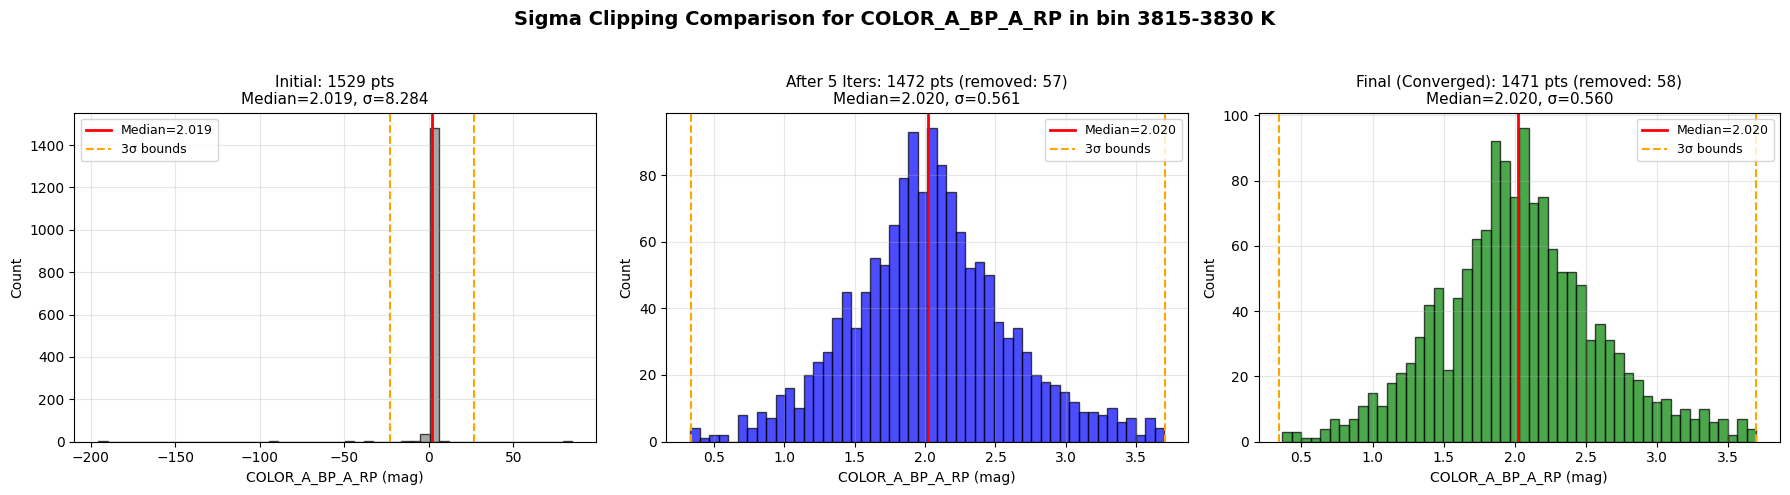


COLOR_A_BP_A_RP in 3815-3830 K:
  Initial:      1529 pts, median=2.0191, std=8.2843
  After 5 its:  1472 pts, median=2.0195, std=0.5615, removed=57
  Final:        1471 pts, median=2.0198, std=0.5599, removed=58
  Difference (5 iters vs converged): 1 additional pts removed


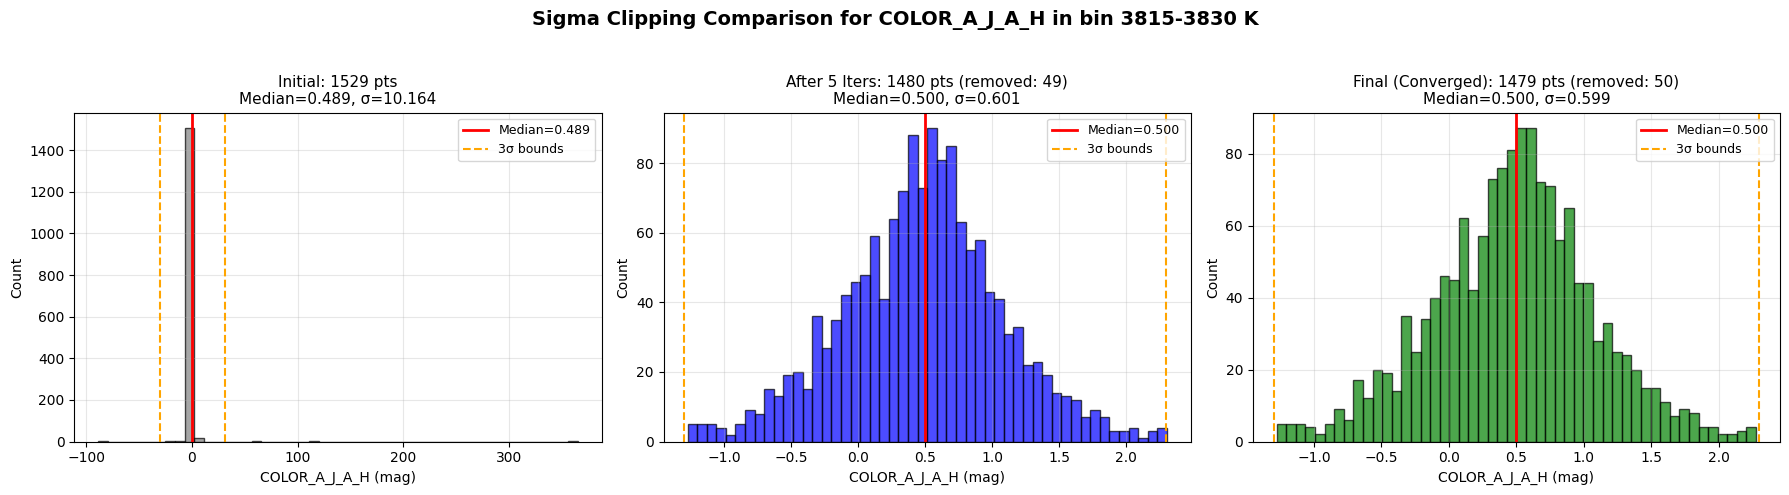


COLOR_A_J_A_H in 3815-3830 K:
  Initial:      1529 pts, median=0.4886, std=10.1641
  After 5 its:  1480 pts, median=0.5005, std=0.6009, removed=49
  Final:        1479 pts, median=0.4997, std=0.5992, removed=50
  Difference (5 iters vs converged): 1 additional pts removed


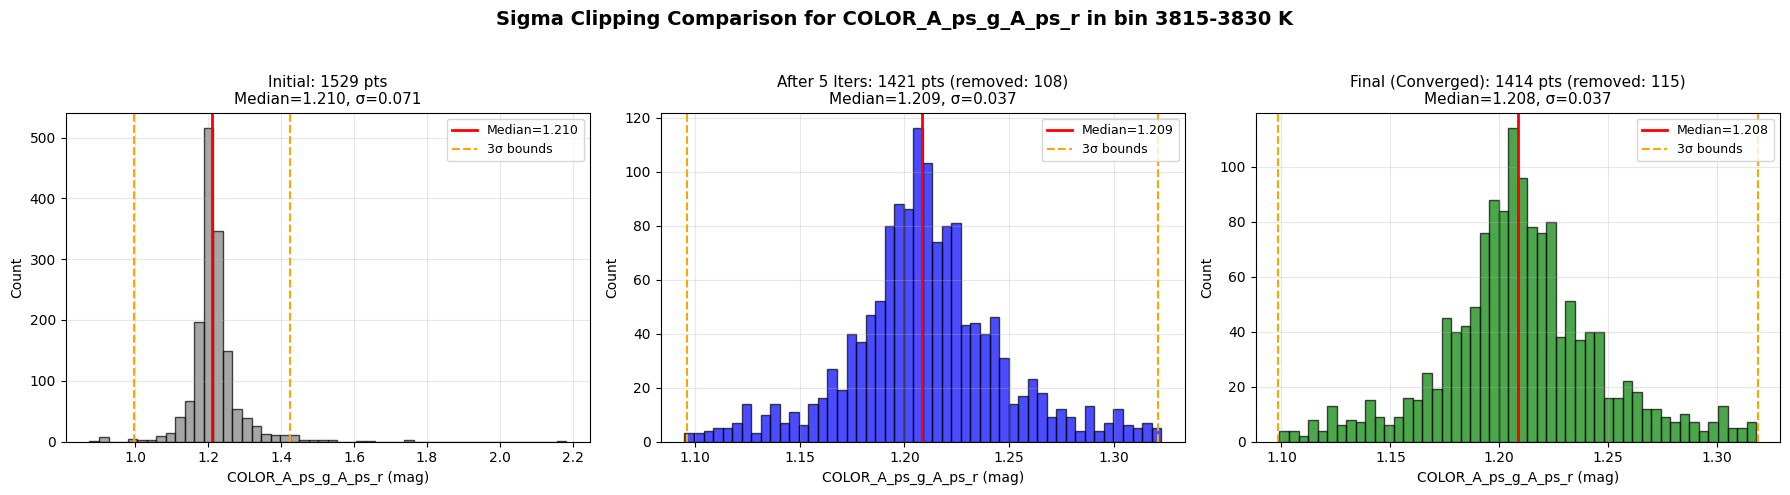


COLOR_A_ps_g_A_ps_r in 3815-3830 K:
  Initial:      1529 pts, median=1.2097, std=0.0711
  After 5 its:  1421 pts, median=1.2086, std=0.0375, removed=108
  Final:        1414 pts, median=1.2085, std=0.0367, removed=115
  Difference (5 iters vs converged): 7 additional pts removed


In [12]:
# Comparison visualization: Initial vs 5 iterations vs Final (converged)
def compare_clipping_iterations(df, color_name, bin_name):
    """
    Compare the effect of sigma clipping at different iteration stages.
    Shows: (1) Initial, (2) After 5 iterations, (3) Final converged result.
    """
    df_bin = df[df['teff_bin'] == bin_name]
    values = df_bin[color_name].dropna()
    
    if len(values) < 10:
        print(f"Not enough data points in bin {bin_name} for {color_name}")
        return
    
    # 1. Initial (no clipping)
    initial_median = np.median(values)
    initial_std = np.std(values)
    
    # 2. After 5 iterations
    clipped_5 = sigma_clip(values, sigma=3.0, maxiters=5, cenfunc='median', stdfunc='std')
    values_5 = values[~clipped_5.mask]
    median_5 = np.median(values_5)
    std_5 = np.std(values_5)
    
    # 3. Final (None iterations = until convergence)
    clipped_final = sigma_clip(values, sigma=3.0, maxiters=None, cenfunc='median', stdfunc='std')
    values_final = values[~clipped_final.mask]
    median_final = np.median(values_final)
    std_final = np.std(values_final)
    
    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: Initial
    ax1 = axes[0]
    ax1.hist(values, bins=50, color='gray', alpha=0.7, edgecolor='black')
    ax1.axvline(initial_median, color='red', linewidth=2, label=f'Median={initial_median:.3f}')
    ax1.axvline(initial_median - 3*initial_std, color='orange', linestyle='--', linewidth=1.5, label=f'3σ bounds')
    ax1.axvline(initial_median + 3*initial_std, color='orange', linestyle='--', linewidth=1.5)
    ax1.set_title(f'Initial: {len(values)} pts\nMedian={initial_median:.3f}, σ={initial_std:.3f}', fontsize=11)
    ax1.set_xlabel(f'{color_name} (mag)')
    ax1.set_ylabel('Count')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: After 5 iterations
    ax2 = axes[1]
    ax2.hist(values_5, bins=50, color='blue', alpha=0.7, edgecolor='black')
    ax2.axvline(median_5, color='red', linewidth=2, label=f'Median={median_5:.3f}')
    ax2.axvline(median_5 - 3*std_5, color='orange', linestyle='--', linewidth=1.5, label=f'3σ bounds')
    ax2.axvline(median_5 + 3*std_5, color='orange', linestyle='--', linewidth=1.5)
    removed_5 = len(values) - len(values_5)
    ax2.set_title(f'After 5 Iters: {len(values_5)} pts (removed: {removed_5})\nMedian={median_5:.3f}, σ={std_5:.3f}', fontsize=11)
    ax2.set_xlabel(f'{color_name} (mag)')
    ax2.set_ylabel('Count')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Final (converged)
    ax3 = axes[2]
    ax3.hist(values_final, bins=50, color='green', alpha=0.7, edgecolor='black')
    ax3.axvline(median_final, color='red', linewidth=2, label=f'Median={median_final:.3f}')
    ax3.axvline(median_final - 3*std_final, color='orange', linestyle='--', linewidth=1.5, label=f'3σ bounds')
    ax3.axvline(median_final + 3*std_final, color='orange', linestyle='--', linewidth=1.5)
    removed_final = len(values) - len(values_final)
    ax3.set_title(f'Final (Converged): {len(values_final)} pts (removed: {removed_final})\nMedian={median_final:.3f}, σ={std_final:.3f}', fontsize=11)
    ax3.set_xlabel(f'{color_name} (mag)')
    ax3.set_ylabel('Count')
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)
    
    plt.suptitle(f'Sigma Clipping Comparison for {color_name} in bin {bin_name}', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    #plt.savefig(RESULTS_DIR / f'clipping_comparison_{color_name}_{bin_name.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print summary
    print(f"\n{color_name} in {bin_name}:")
    print(f"  Initial:     {len(values):5d} pts, median={initial_median:.4f}, std={initial_std:.4f}")
    print(f"  After 5 its: {len(values_5):5d} pts, median={median_5:.4f}, std={std_5:.4f}, removed={removed_5}")
    print(f"  Final:       {len(values_final):5d} pts, median={median_final:.4f}, std={std_final:.4f}, removed={removed_final}")
    print(f"  Difference (5 iters vs converged): {removed_final - removed_5} additional pts removed")

# Show comparison for representative colors and bins
print("=" * 80)
print("=== COMPARISON VISUALIZATIONS: Initial vs 5 Iters vs Converged ===")
print("=" * 80)

# Get middle bin for representative comparison
teff_bins_available = sorted(df['teff_bin'].dropna().unique())
middle_bin_idx = len(teff_bins_available) // 2
representative_bin = teff_bins_available[middle_bin_idx]

# Show comparisons for a few representative colors
representative_colors = ['COLOR_A_BP_A_RP', 'COLOR_A_J_A_H', 'COLOR_A_ps_g_A_ps_r']
for color in representative_colors:
    if color in color_combinations:
        compare_clipping_iterations(df, color, representative_bin)

In [13]:
# Summary table: Compare 5 iterations vs converged across ALL colors
print("\n" + "=" * 80)
print("=== SUMMARY: 5 Iterations vs Full Convergence (All Colors) ===")
print("=" * 80)

summary_data = []
for color_name in color_combinations.keys():
    total_original = sum(s['original_N'] for s in convergence_stats[color_name].values())
    total_removed_5 = sum(s['removed_5_iters'] for s in convergence_stats[color_name].values())
    total_removed_final = sum(s['removed_final'] for s in convergence_stats[color_name].values())
    diff = total_removed_final - total_removed_5
    
    summary_data.append({
        'Color': color_name,
        'Total': total_original,
        'Removed (5 iters)': total_removed_5,
        'Removed (converged)': total_removed_final,
        'Extra removed': diff,
        '% Removed (5 iters)': f"{100*total_removed_5/total_original:.2f}%",
        '% Removed (converged)': f"{100*total_removed_final/total_original:.2f}%"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Overall summary
total_original_all = sum(s['Total'] for s in summary_data)
total_removed_5_all = sum(s['Removed (5 iters)'] for s in summary_data)
total_removed_final_all = sum(s['Removed (converged)'] for s in summary_data)

print(f"\n--- Overall (summed across all colors) ---")
print(f"Total data points (all colors combined): {total_original_all}")
print(f"Total removed after 5 iterations: {total_removed_5_all}")
print(f"Total removed after convergence: {total_removed_final_all}")
print(f"Additional removed by convergence: {total_removed_final_all - total_removed_5_all}")


=== SUMMARY: 5 Iterations vs Full Convergence (All Colors) ===
              Color  Total  Removed (5 iters)  Removed (converged)  Extra removed % Removed (5 iters) % Removed (converged)
  COLOR_A_BAP_A_GSD  30569               1014                 1049             35               3.32%                 3.43%
 COLOR_A_BAP_A_ps_g  30569               1181                 1226             45               3.86%                 4.01%
   COLOR_A_BAP_A_BP  30569               1184                 1242             58               3.87%                 4.06%
  COLOR_A_BAP_A_VAP  30569               1097                 1135             38               3.59%                 3.71%
 COLOR_A_BAP_A_ps_r  30569               1188                 1226             38               3.89%                 4.01%
  COLOR_A_BAP_A_RSD  30569               1154                 1219             65               3.78%                 3.99%
  COLOR_A_BAP_A_RAP  30569               1108                 1150  

## Phase 6: Save Filtered Dataset

Create clean dataset and save.

In [14]:
df_clean = df[~df['outlier_consensus']].copy()
df_outliers = df[df['outlier_consensus']].copy()

cols_to_drop = outlier_columns + ['teff_bin', 'outlier_consensus']
df_clean_out = df_clean.drop(columns=cols_to_drop, errors='ignore')

clean_path = r'C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\data\outlier_filtering_results\Xmatch_gaia_LAMOST_LAMOSTvac_M_dwarfs_clean.csv'
df_clean_out.to_csv(clean_path, index=False)

print(f"Clean dataset saved: {len(df_clean_out)} stars -> {clean_path}")

Clean dataset saved: 17798 stars -> C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\data\outlier_filtering_results\Xmatch_gaia_LAMOST_LAMOSTvac_M_dwarfs_clean.csv


## Phase 7: Sanity Check For Cleaned Dataset

Using the cleaned dataset (after outlier removal), generate comprehensive visualization for:
1. Color distributions plots (ALL colors)
2. ALL color vs Teff plots without outliers
3. Bin-wise plots for ALL colors (detailed distributions per Teff bin)

In [15]:
# Load the cleaned dataset for comprehensive visualization
clean_data_path = r'C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\data\outlier_filtering_results\Xmatch_gaia_LAMOST_LAMOSTvac_M_dwarfs_clean.csv'

df_clean_viz = pd.read_csv(clean_data_path)

print(f"Cleaned dataset loaded for viz: {len(df_clean_viz)} stars")
# ...existing code...
for color_name, (mag1, mag2) in color_combinations.items():
    df_clean_viz[color_name] = df_clean_viz[mag1] - df_clean_viz[mag2]

# Apply the same adaptive bins (using edges calculated in Phase 3)
# Changed to include_lowest=True to match the definition above
df_clean_viz['teff_bin'] = pd.cut(
    df_clean_viz['teff'], teff_bins, include_lowest=True,
    labels=[f'{teff_bins[i]:.0f}-{teff_bins[i+1]:.0f} K' for i in range(len(teff_bins)-1)]
)
# ...existing code...

"""# Recompute colors for the viz dataframe
for color_name, (mag1, mag2) in color_combinations.items():
    df_clean_viz[color_name] = df_clean_viz[mag1] - df_clean_viz[mag2]

df_clean_viz['teff_bin'] = pd.cut(
    df_clean_viz['teff'], teff_bins, right=False,
    labels=[f'{teff_bins[i]:.0f}-{teff_bins[i+1]:.0f} K' for i in range(len(teff_bins)-1)]
)"""

Cleaned dataset loaded for viz: 17798 stars


"# Recompute colors for the viz dataframe\nfor color_name, (mag1, mag2) in color_combinations.items():\n    df_clean_viz[color_name] = df_clean_viz[mag1] - df_clean_viz[mag2]\n\ndf_clean_viz['teff_bin'] = pd.cut(\n    df_clean_viz['teff'], teff_bins, right=False,\n    labels=[f'{teff_bins[i]:.0f}-{teff_bins[i+1]:.0f} K' for i in range(len(teff_bins)-1)]\n)"

In [16]:
df_clean_viz.columns.tolist()

['obsid',
 'subclass',
 'gaia_source_id',
 'distance_gaia_pc',
 'teff',
 'logg',
 'A_GG',
 'A_BP',
 'A_RP',
 'A_J',
 'A_H',
 'A_KS',
 'A_W1',
 'A_W2',
 'A_BAP',
 'A_VAP',
 'A_RAP',
 'A_GSD',
 'A_RSD',
 'A_ISD',
 'A_ps_g',
 'A_ps_r',
 'A_ps_i',
 'A_ps_z',
 'A_ps_y',
 'COLOR_A_BAP_A_GSD',
 'COLOR_A_BAP_A_ps_g',
 'COLOR_A_BAP_A_BP',
 'COLOR_A_BAP_A_VAP',
 'COLOR_A_BAP_A_ps_r',
 'COLOR_A_BAP_A_RSD',
 'COLOR_A_BAP_A_RAP',
 'COLOR_A_BAP_A_GG',
 'COLOR_A_BAP_A_ps_i',
 'COLOR_A_BAP_A_ISD',
 'COLOR_A_BAP_A_RP',
 'COLOR_A_BAP_A_ps_z',
 'COLOR_A_BAP_A_ps_y',
 'COLOR_A_BAP_A_J',
 'COLOR_A_BAP_A_H',
 'COLOR_A_BAP_A_KS',
 'COLOR_A_BAP_A_W1',
 'COLOR_A_BAP_A_W2',
 'COLOR_A_GSD_A_ps_g',
 'COLOR_A_GSD_A_BP',
 'COLOR_A_GSD_A_VAP',
 'COLOR_A_GSD_A_ps_r',
 'COLOR_A_GSD_A_RSD',
 'COLOR_A_GSD_A_RAP',
 'COLOR_A_GSD_A_GG',
 'COLOR_A_GSD_A_ps_i',
 'COLOR_A_GSD_A_ISD',
 'COLOR_A_GSD_A_RP',
 'COLOR_A_GSD_A_ps_z',
 'COLOR_A_GSD_A_ps_y',
 'COLOR_A_GSD_A_J',
 'COLOR_A_GSD_A_H',
 'COLOR_A_GSD_A_KS',
 'COLOR_A_GSD_A_

In [17]:
df_clean_viz.head()

,obsid,subclass,gaia_source_id,distance_gaia_pc,teff,logg,A_GG,A_BP,A_RP,A_J,...,COLOR_A_J_A_KS,COLOR_A_J_A_W1,COLOR_A_J_A_W2,COLOR_A_H_A_KS,COLOR_A_H_A_W1,COLOR_A_H_A_W2,COLOR_A_KS_A_W1,COLOR_A_KS_A_W2,COLOR_A_W1_A_W2,teff_bin
0,435215169,dM0,3993609820459698944,432.921102,3742.17,4.711,6.377618,7.248051,5.124525,3.803340,...,2.401711,0.828106,2.720979,1.932714,0.359109,2.251982,-1.573605,0.319268,1.892873,3737-3751 K
1,535601153,dM1,950539351380509184,124.065213,3665.66,4.789,5.484379,7.745889,5.052029,3.660513,...,2.305455,0.724732,2.530998,2.722594,1.141871,2.948137,-1.580723,0.225543,1.806267,3658-3676 K
2,712905150,dM1,654638056263893120,449.526948,3732.71,4.672,5.039354,6.593801,5.313258,3.956082,...,2.268265,0.595564,2.477817,1.832622,0.159922,2.042175,-1.672700,0.209553,1.882253,3723-3737 K
3,236513211,dM0,4439887807624987904,273.548810,3843.78,4.668,5.718608,7.957727,5.720991,4.906968,...,0.860446,1.536681,2.237931,0.317896,0.994132,1.695381,0.676235,1.377485,0.701250,3844-3857 K
4,470201136,dM0,232680819633278720,213.538022,3743.31,4.710,5.909266,7.498632,5.455059,4.042896,...,1.141231,0.734150,1.545619,1.208381,0.801300,1.612769,-0.407081,0.404388,0.811469,3737-3751 K


In [18]:
df_M = pd.read_csv(r'C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\data\Xmatch_result\Xmatch_gaia_LAMOST_LAMOSTvac_M_dwarf.csv')
df_M.head()

,obsid,subclass,gaia_source_id,Gmag,BPmag,RPmag,distance_gaia_pc,mag_ps_g,mag_ps_r,mag_ps_i,...,A_H,A_KS,A_W1,A_W2,A_BAP,A_VAP,A_RAP,A_GSD,A_RSD,A_ISD
0,435215169,dM0,3993609820459698944,16.427471,17.398817,15.385714,432.921102,17.7917,16.590799,15.7982,...,3.334343,1.401629,2.975234,1.082361,8.561455,7.137291,6.344064,5.140104,5.409916,4.833805
1,535601153,dM1,950539351380509184,14.445332,15.579183,13.387507,124.065213,15.9545,14.749600,13.8214,...,4.077652,1.355058,2.935781,1.129515,8.329693,6.717271,7.282686,4.979917,5.084450,5.009765
2,554809170,dM0,1607347392624323200,13.306873,14.176715,12.298207,118.271846,14.5828,13.363200,12.9440,...,5.021838,4.349710,4.735013,3.933988,9.987725,9.150569,8.297882,8.147628,7.389708,7.583855
3,627112105,dM0,3334763520882424960,14.575844,15.357343,13.245786,271.819252,15.7892,14.616000,13.4790,...,1.541595,0.536480,1.229321,0.239162,6.890810,6.230767,5.476501,4.756032,4.547402,4.293331
4,601207039,dM4,1095944919432789376,15.473381,16.701200,14.364461,240.911221,17.0826,15.902600,14.7809,...,1.224484,-2.790304,-0.482852,-1.735435,5.608651,4.970146,5.396399,2.319138,1.674421,2.019479


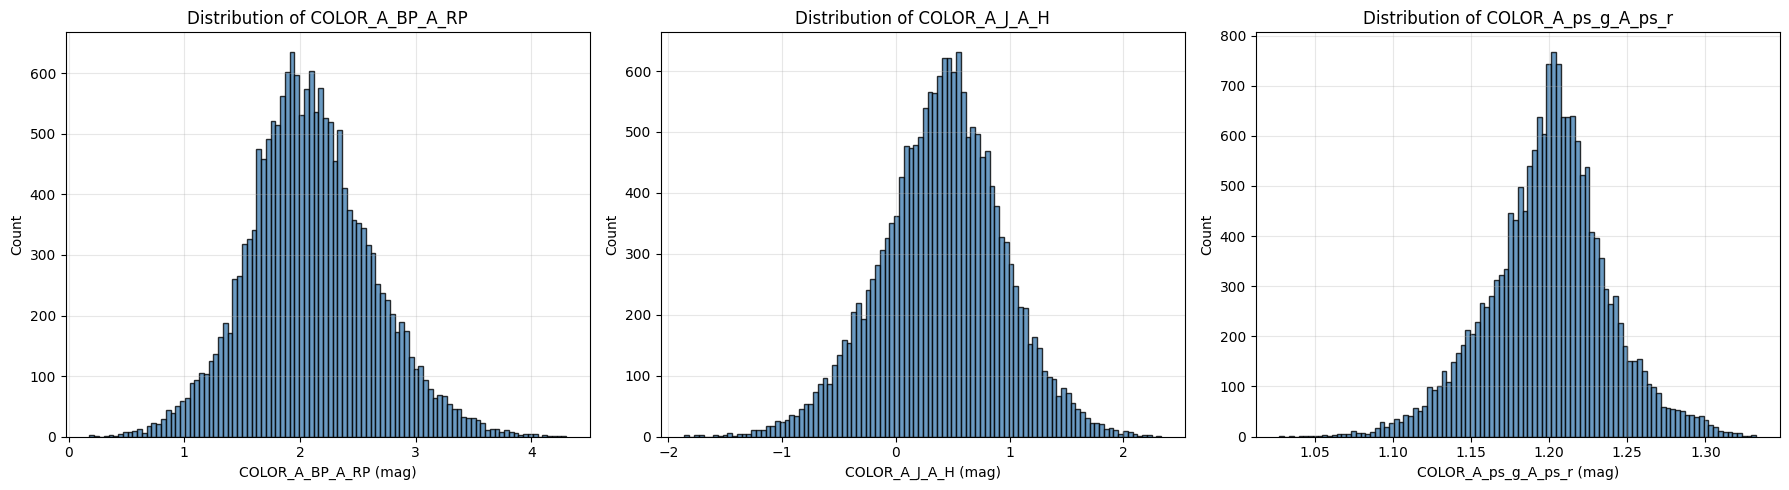

In [19]:
# 1. Color distribution plots for ALL colors (6x3 grid for 17 colors)
n_colors = len(representative_colors)
n_cols = 3
n_rows = (n_colors + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, color_name in enumerate(representative_colors):
    ax = axes[i]
    df_clean_viz[color_name].plot.hist(bins=100, ax=ax, alpha=0.8, color='steelblue', edgecolor='black')
    ax.set_xlabel(f'{color_name} (mag)')
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution of {color_name}')
    ax.grid(True, alpha=0.3)

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.tight_layout()
#plt.savefig(RESULTS_DIR / 'clean_color_distributions_all.png', dpi=150, bbox_inches='tight')
plt.show()

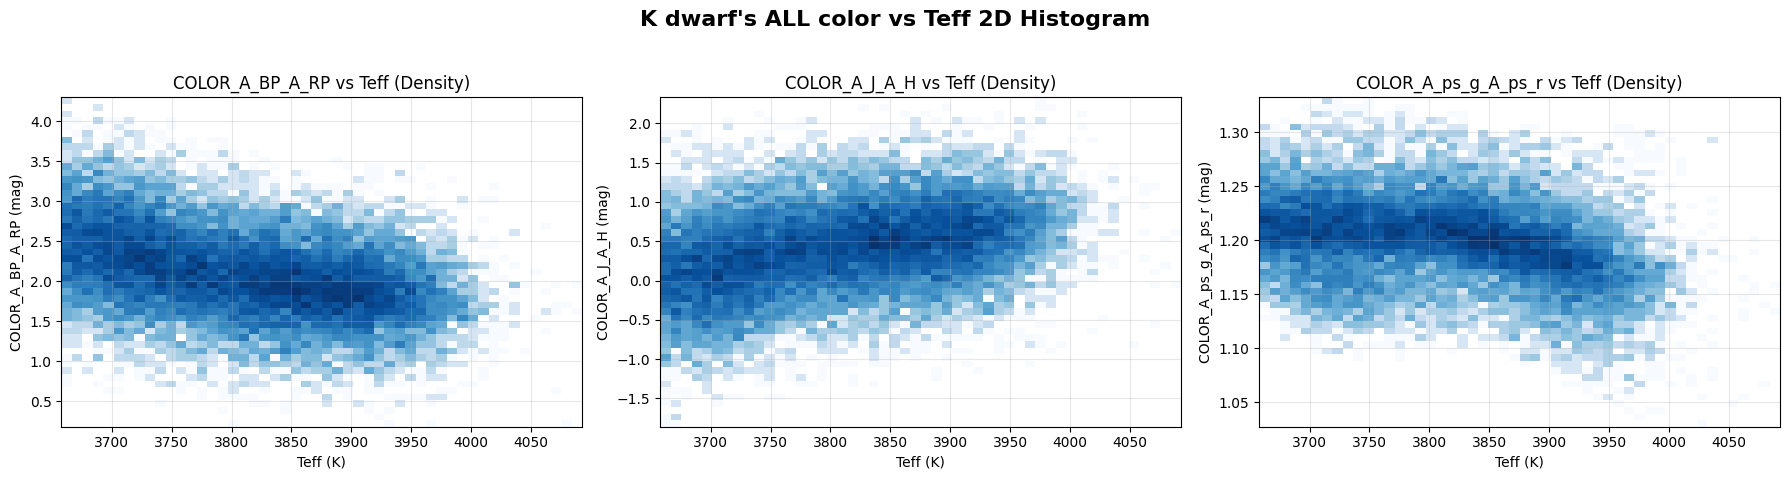

In [20]:
from matplotlib.colors import LogNorm

# 2. ALL color vs Teff plots (2D Histograms)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, color_name in enumerate(representative_colors):
    ax = axes[i]
    # Use 2D histogram with log scale to show density
    h = ax.hist2d(df_clean_viz['teff'], df_clean_viz[color_name], 
                  bins=50, cmap='Blues', norm=LogNorm(), cmin=1)
    
    ax.set_xlabel('Teff (K)')
    ax.set_ylabel(f'{color_name} (mag)')
    ax.set_title(f'{color_name} vs Teff (Density)')
    ax.grid(True, alpha=0.3)

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle("K dwarf's ALL color vs Teff 2D Histogram", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
#plt.savefig(RESULTS_DIR / 'clean_all_colors_vs_teff_density.png', dpi=150, bbox_inches='tight')
plt.show()

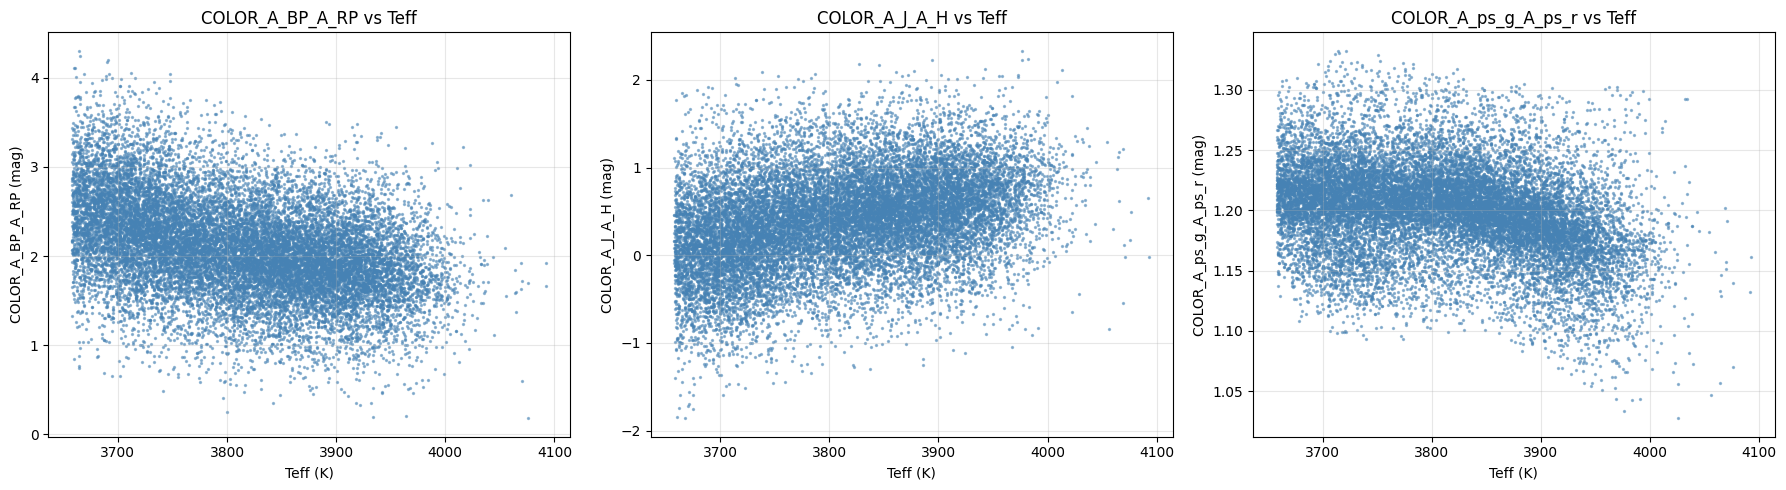

In [21]:
# 2. ALL color vs Teff plots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, color_name in enumerate(representative_colors):
    ax = axes[i]
    ax.scatter(df_clean_viz['teff'], df_clean_viz[color_name], color='steelblue', alpha=0.5, s=2)
    ax.set_xlabel('Teff (K)')
    ax.set_ylabel(f'{color_name} (mag)')
    ax.set_title(f'{color_name} vs Teff')
    ax.grid(True, alpha=0.3)

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.tight_layout()
#plt.savefig(RESULTS_DIR / 'clean_all_colors_vs_teff.png', dpi=150, bbox_inches='tight')
plt.show()